In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("cleaned_data.csv")
df.head()

,experience_id,imported_class_year,imported_program,imported_unit,major_department,major_unit,notes,person_id,record_id,registrar_class_year,...,participant_programs_unique,participant_record_id_unique,uniqname,registrar_department.1,registrar_program,registrar_type,registrar_unit.1,term_season,year,student_name
0,182.0,Sophomore,Dance BFA,NaN,Dance,"Music, Theatre & Dance",Credit Hours: 1,415.0,689.0,Sophomore,...,Dance BFA,689.0,abniemi,Dance,Dance BFA,Major,"Music, Theatre & Dance",FA,2019,Abby Niemi
1,182.0,Sophomore,Dance BFA,NaN,Dance,"Music, Theatre & Dance",Credit Hours: 1,415.0,689.0,Sophomore,...,Dance BFA Dance BFA,14905.0,abniemi,Dance,Dance BFA,Major,"Music, Theatre & Dance",FA,2019,Abby Niemi
2,178.0,Sophomore,Theatre BTA,NaN,Theatre & Drama,"Music, Theatre & Dance",Credit Hours: 1,416.0,690.0,Sophomore,...,Theatre BTA,690.0,acurnow,Theatre & Drama,Theatre BTA,Major,"Music, Theatre & Dance",FA,2019,Alix Curnow
3,178.0,Sophomore,Theatre BTA,NaN,Theatre & Drama,"Music, Theatre & Dance",Credit Hours: 1,416.0,690.0,Sophomore,...,Theatre BTA,2666.0,acurnow,Theatre & Drama,Theatre BTA,Major,"Music, Theatre & Dance",FA,2019,Alix Curnow
4,178.0,Sophomore,Theatre BTA,NaN,Theatre & Drama,"Music, Theatre & Dance",Credit Hours: 1,416.0,690.0,Sophomore,...,Theatre BTA Minor -Playwriting BTA,9947.0,acurnow,Theatre & Drama,Theatre BTA,Major,"Music, Theatre & Dance",FA,2019,Alix Curnow


In [7]:
# delete import_unit
# 

In [8]:
import pandas as pd

# Total students (First Contact)
total_students = df["person_id"].nunique()

# Experiences per student
exp_counts = df.groupby("person_id")["experience_id"].count()

# Conversion: ≥2 experiences
converted = (exp_counts >= 2).sum()
conversion_rate = converted / total_students

# Retention prep: years per student
years_per_student = df.groupby("person_id")["year"].unique()

def retained_1yr(years):
    years = sorted(years)
    return any(y+1 in years for y in years)

def retained_2yr(years):
    years = sorted(years)
    return any(y+2 in years for y in years)

retained_1 = years_per_student.apply(retained_1yr).sum()
retained_2 = years_per_student.apply(retained_2yr).sum()

retention_1_rate = retained_1 / total_students
retention_2_rate = retained_2 / total_students

# Avg depth
avg_depth = exp_counts.mean()

In [9]:
funnel_df = pd.DataFrame({
    "Stage": [
        "First Contact",
        "Conversion",
        "Retention 1yr",
        "Retention 2yr",
        "Avg Depth"
    ],
    "Metric": [
        total_students,
        conversion_rate,
        retention_1_rate,
        retention_2_rate,
        avg_depth
    ]
})

funnel_df

,Stage,Metric
0,First Contact,5149.000000
1,Conversion,0.625170
2,Retention 1yr,0.346281
3,Retention 2yr,0.218683
4,Avg Depth,35.209167


In [10]:
funnel_df["Metric"] = funnel_df.apply(
    lambda row: f"{row['Metric']:.2%}" if "Retention" in row["Stage"] or "Conversion" in row["Stage"]
    else f"{row['Metric']:.2f}" if row["Stage"] == "Avg Depth"
    else int(row["Metric"]),
    axis=1
)

funnel_df

,Stage,Metric
0,First Contact,5149
1,Conversion,62.52%
2,Retention 1yr,34.63%
3,Retention 2yr,21.87%
4,Avg Depth,35.21


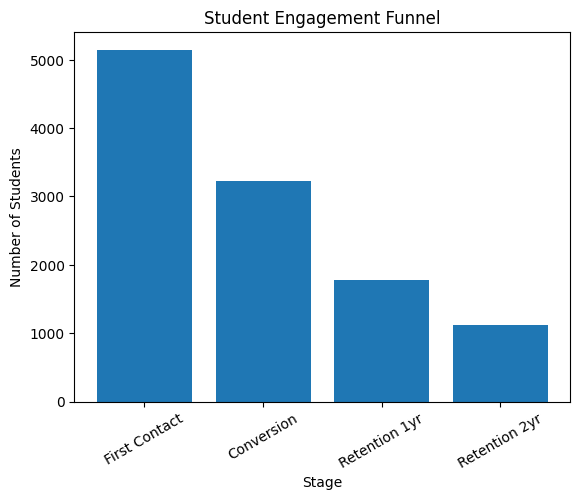

In [11]:
import matplotlib.pyplot as plt

# Convert percentages back to numeric for plotting
plot_df = pd.DataFrame({
    "Stage": ["First Contact", "Conversion", "Retention 1yr", "Retention 2yr"],
    "Value": [
        total_students,
        conversion_rate * total_students,
        retention_1_rate * total_students,
        retention_2_rate * total_students
    ]
})

plt.figure()
plt.bar(plot_df["Stage"], plot_df["Value"])
plt.title("Student Engagement Funnel")
plt.xlabel("Stage")
plt.ylabel("Number of Students")
plt.xticks(rotation=30)
plt.show()